# TASK: trajectory generation in Cartesian space

Given a start point, a via point, and an end point in Cartesian space, along with their corresponding timestamps, fit a fifth-order polynomial trajectory that passes through all three points at their respective times.

   Use the following data:

   - start point = [0, 1, 2]
   - via point = [4, 5, 3]
   - end point = [8, 2, 6]

   - start velocity = [0, 0, 0]
   - via velocity = [0, 1, -1]
   - end velocity = [0, 0, 0]

   - start time = 0.0
   - via time = 2.0
   - end time = 5.0

Answer the following questions:

1. Fit the fifth-order polynomial trajectory.
2. Plot the generated 3D curve.
3. Output (print) the polynomial coefficient matrix.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Fifth-order polynomial trajectory
# our trajectory (model) is:
# x(t) = a5_x * t^5 + a4_x * t^4 + a3_x * t^3 + a2_x * t^2 + a1_x * t + a0_x
# y(t) = a5_y * t^5 + a4_y * t^4 + a3_y * t^3 + a2_y * t^2 + a1_y * t + a0_y
# z(t) = a5_z * t^5 + a4_z * t^4 + a3_z * t^3 + a2_z * t^2 + a1_z * t + a0_z

# define the time, position and velocity of start point, via point and end-point
start_point = np.array([0.0, 1.0, 2.0])
via_point = np.array([4.0, 5.0, 3.0])
end_point = np.array([8.0, 2.0, 6.0])

start_vel = np.array([0.0, 0.0, 0.0])
via_vel = np.array([0.0, 1.0, -1.0])
end_vel = np.array([0.0, 0.0, 0.0])

points = np.array([
    start_point,
    via_point,
    end_point
])
velocities = np.array([
    start_vel,
    via_vel,
    end_vel
])
start_time, via_time, end_time = 0.0, 2.0, 5.0

Computing polynomial coefficients...
Coefficients computed successfully.


Text(0.5, 0.92, 'Fifth-Order Polynomial Trajectory')

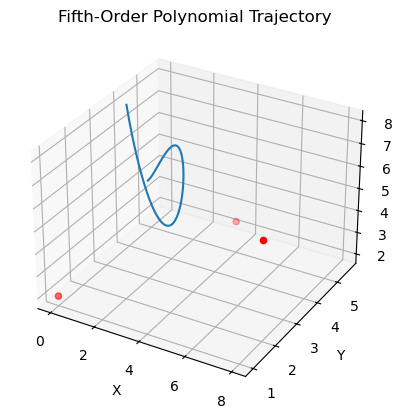

In [6]:
def compute_polynomial_coefficients(points, velocities, times):
    a = np.zeros((3, 6))  # 3 dimensions, 6 coefficients each
    for i in range(3):  # for x, y, z
        A = np.array([
            [times[0]**5, times[0]**4, times[0]**3, times[0]**2, times[0], 1],
            [times[1]**5, times[1]**4, times[1]**3, times[1]**2, times[1], 1],
            [times[2]**5, times[2]**4, times[2]**3, times[2]**2, times[2], 1],
            [5*times[0]**4, 4*times[0]**3, 3*times[0]**2, 2*times[0], 1, 0],
            [5*times[1]**4, 4*times[1]**3, 3*times[1]**2, 2*times[1], 1, 0],
            [5*times[2]**4, 4*times[2]**3, 3*times[2]**2, 2*times[2], 1, 0]
        ])
        b = np.array([
            points[i][0],
            points[i][1],
            points[i][2],
            velocities[i][0],
            velocities[i][1],
            velocities[i][2]
        ])
        a[i] = np.linalg.solve(A, b)
    return a

print("Computing polynomial coefficients...")
coefficients = compute_polynomial_coefficients(points, velocities, [start_time, via_time, end_time])
print("Coefficients computed successfully.")

# Visualise the trajectory
time_steps = np.linspace(start_time, end_time, 100)
trajectory = np.zeros((100, 3))
for i in range(3):
    trajectory[:, i] = (coefficients[i][0] * time_steps**5 +
                        coefficients[i][1] * time_steps**4 +
                        coefficients[i][2] * time_steps**3 +
                        coefficients[i][3] * time_steps**2 +
                        coefficients[i][4] * time_steps +
                        coefficients[i][5])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], label='Trajectory')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='red', label='Key Points')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Fifth-Order Polynomial Trajectory')